# MW/RF ordering test for a $^{14}$N NV center

This notebook compares two deliberately simple pulse sequences in the full nine-state electronic-spin/nuclear-spin Hilbert space. Sequence A turns on the RF dressing field first and keeps its envelope on until a final ramp-down while a single MW pulse addresses $|0,0\rangle\leftrightarrow|-1,0\rangle$. Sequence B reverses the **onset ordering**: the same MW pulse is completed first, then the RF pulse is applied. This is the explicit interpretation of “reverse the ordering/envelopes”; pulse amplitudes, ramp durations, total time, and carrier resonance conditions are otherwise held fixed.

The dynamics are evaluated in the resonant rotating-wave frame. The static NV Hamiltonian is still used to derive every state, transition frequency, projector, and physical drive matrix element. This avoids resolving a multi-GHz carrier on a microsecond time grid and makes the ordering comparison transparent.


## 1) Define the NV system (B0 = 2 mT, N = 14)

QuaCCAToo supplies the physical ground-state NV Hamiltonian and the MW/RF control operators. For $S=1$ and the intrinsic $^{14}$N nucleus ($I=1$), the Hilbert-space dimension is $3\times3=9$.


In [26]:
from itertools import permutations

import numpy as np
import matplotlib.pyplot as plt

from qutip import basis, expect, ket2dm, qeye, tensor
from quaccatoo import NV, PulsedSim, QSys

plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.3})

B0_mT = 2.0
nv = NV(B0=B0_mT, units_B0="mT", N=14)
nv.rho0 = nv.rho0 / nv.rho0.tr()

print("Hamiltonian shape:", nv.H0.shape)
print("Initial-state trace:", nv.rho0.tr())
print("QuaCCAToo MW reference frequencies (MHz):", nv.MW_freqs)
print("QuaCCAToo RF reference frequencies (MHz):", nv.RF_freqs)

assert nv.H0.shape == (9, 9)
assert np.isclose(nv.rho0.tr(), 1.0)

TRANSITION = "e-<->g-"

Hamiltonian shape: (9, 9)
Initial-state trace: 1.0
QuaCCAToo MW reference frequencies (MHz): [2813.95521046 2926.05494991]
QuaCCAToo RF reference frequencies (MHz): [5.0013449  5.01355399 7.14643206 2.87614681 2.86383924 7.15864115]


## 2) Derive energy separations between ground and excited states

Here “ground” denotes the predominantly $m_s=0$ manifold and “excited” denotes the predominantly $m_s=-1$ manifold (not the optical excited state). We diagonalize `nv.H0`, classify eigenstates by electron-spin weight, and label each triplet by maximum overlap with the product states in nuclear order $m_I=(-1,0,+1)$. The reported transition frequencies therefore include the Hamiltonian's hyperfine mixing.


In [27]:
# QuTiP spin-1 basis ordering is m=(+1, 0, -1).
ground_references = tuple(tensor(basis(3, 1), basis(3, i)) for i in (2, 1, 0))
excited_references = tuple(tensor(basis(3, 2), basis(3, i)) for i in (2, 1, 0))
state_labels = ("-1", "0", "+1")

P_ms_zero = tensor(ket2dm(basis(3, 1)), qeye(3))
P_ms_minus = tensor(ket2dm(basis(3, 2)), qeye(3))
eigenenergies_mhz, eigenstates = nv.H0.eigenstates()

ground_candidates = [s for s in eigenstates if expect(P_ms_zero, s) >= 0.5]
excited_candidates = [s for s in eigenstates if expect(P_ms_minus, s) >= 0.5]

def order_by_reference(candidates, references):
    overlaps = np.array([[abs(ref.overlap(s))**2 for s in candidates] for ref in references])
    order = max(permutations(range(3)), key=lambda p: sum(overlaps[row, p[row]] for row in range(3)))
    return tuple(candidates[i] for i in order), overlaps[:, order]

ground_states, ground_overlaps = order_by_reference(ground_candidates, ground_references)
excited_states, excited_overlaps = order_by_reference(excited_candidates, excited_references)
ground_energies_mhz = np.array([float(expect(nv.H0, s)) for s in ground_states])
excited_energies_mhz = np.array([float(expect(nv.H0, s)) for s in excited_states])

mw_transition_frequencies_mhz = np.abs(excited_energies_mhz - ground_energies_mhz)
rf_transition_frequencies_mhz = np.abs(np.diff(excited_energies_mhz))

print("Ground energies, mI=(-1,0,+1) (MHz):", ground_energies_mhz)
print("Excited energies, mI=(-1,0,+1) (MHz):", excited_energies_mhz)
print("Matched MW separations (MHz):", mw_transition_frequencies_mhz)
print("Adjacent excited-manifold RF separations (MHz):", rf_transition_frequencies_mhz)
print("Ground assignment overlaps:\n", ground_overlaps)
print("Excited assignment overlaps:\n", excited_overlaps)

assert len(ground_states) == len(excited_states) == 3
assert np.min(np.diag(ground_overlaps)) > 0.5
assert np.min(np.diag(excited_overlaps)) > 0.5


Ground energies, mI=(-1,0,+1) (MHz): [-5.00643206 -0.00508716 -5.01864115]
Excited energies, mI=(-1,0,+1) (MHz): [2806.80625123 2813.95268329 2811.07653648]
Matched MW separations (MHz): [2811.81268329 2813.95777045 2816.09517763]
Adjacent excited-manifold RF separations (MHz): [7.14643206 2.87614681]
Ground assignment overlaps:
 [[0.99999908 0.         0.        ]
 [0.         0.99999822 0.        ]
 [0.         0.         0.99999915]]
Excited assignment overlaps:
 [[1.         0.         0.        ]
 [0.         0.99999908 0.        ]
 [0.         0.         0.99999908]]


## 3) Create projection operators for each ground/excited state from eigenstates of the NV Hamiltonian

The six one-state projectors below are constructed from the derived eigenkets, rather than ideal product kets. Their orthogonality and closure within the two selected manifolds are checked explicitly.


In [28]:
ground_projectors = {f"P_g_{label}": ket2dm(state) for label, state in zip(state_labels, ground_states)}
excited_projectors = {f"P_e_{label}": ket2dm(state) for label, state in zip(state_labels, excited_states)}
projectors = {**ground_projectors, **excited_projectors}

P_ground = sum(ground_projectors.values())
P_excited = sum(excited_projectors.values())
P_selected = P_ground + P_excited

projector_overlap = np.array([
    [float(np.real((Pa * Pb).tr())) for Pb in projectors.values()]
    for Pa in projectors.values()
])
print("Projectors:", tuple(projectors))
print("Tr(P_i P_j):\n", projector_overlap)
print("Selected six-state projector trace:", P_selected.tr())

assert np.allclose(projector_overlap, np.eye(6), atol=1e-10)
assert np.isclose(P_selected.tr(), 6.0)

# States requested for the single MW transition.
g_minus = ground_states[0]
g0 = ground_states[1]
g_plus = ground_states[2]
e_minus = excited_states[0]
e0 = excited_states[1]
e_plus = excited_states[2]
P_g0 = ground_projectors["P_g_0"]
P_e0 = excited_projectors["P_e_0"]


Projectors: ('P_g_-1', 'P_g_0', 'P_g_+1', 'P_e_-1', 'P_e_0', 'P_e_+1')
Tr(P_i P_j):
 [[1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 1.]]
Selected six-state projector trace: 6.000000000000001


## 4) Create the RF and MW pulse envelopes

Both controls use smooth $\sin^2$ edges. In sequence A the RF field ramps up at the beginning, remains at full amplitude across the MW pulse, and ramps down at the end. In sequence B the MW pulse occurs first and the RF pulse follows, so their onset order is reversed without changing either pulse's peak Rabi frequency or edge duration.

The RF drive contains the two resonant tones needed to couple adjacent $m_I$ states in the $m_s=-1$ manifold. The MW drive contains only the resonant $|0,0\rangle\leftrightarrow|-1,0\rangle$ tone.


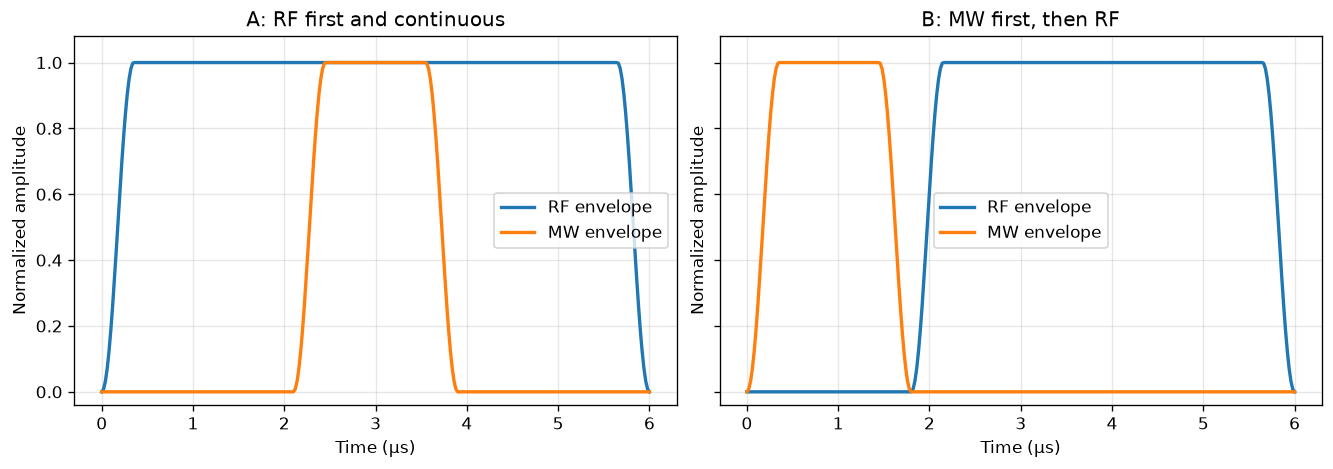

In [29]:
TOTAL_TIME_US = 6.0
RAMP_US = 0.35
MW_DURATION_US = 1.8
RF_RABI_MHZ = 0.35
MW_RABI_MHZ = 0.50

t_us = np.linspace(0.0, TOTAL_TIME_US, 301)

def smooth_window(t, start, stop, ramp):
    """Unit-height window with sin^2 turn-on and turn-off edges."""
    t = np.asarray(t, dtype=float)
    if not (start < stop and 0 < ramp <= 0.5 * (stop - start)):
        raise ValueError("Require start < stop and 0 < ramp <= half the window length")
    y = np.zeros_like(t)
    rising = (t >= start) & (t < start + ramp)
    plateau = (t >= start + ramp) & (t <= stop - ramp)
    falling = (t > stop - ramp) & (t <= stop)
    y[rising] = np.sin(0.5 * np.pi * (t[rising] - start) / ramp)**2
    y[plateau] = 1.0
    y[falling] = np.sin(0.5 * np.pi * (stop - t[falling]) / ramp)**2
    # QuTiP requires a number for scalar solver time, not a 0-D ndarray.
    return y.item() if y.ndim == 0 else y

def envelope_A_rf(t):
    return smooth_window(t, 0.0, TOTAL_TIME_US, RAMP_US)

def envelope_A_mw(t):
    return smooth_window(t, 2.1, 2.1 + MW_DURATION_US, RAMP_US)

def envelope_B_mw(t):
    return smooth_window(t, 0.0, MW_DURATION_US, RAMP_US)

def envelope_B_rf(t):
    return smooth_window(t, MW_DURATION_US, TOTAL_TIME_US, RAMP_US)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharex=True, sharey=True, constrained_layout=True)
for ax, title, rf_env, mw_env in (
    (axes[0], "A: RF first and continuous", envelope_A_rf, envelope_A_mw),
    (axes[1], "B: MW first, then RF", envelope_B_rf, envelope_B_mw),
):
    ax.plot(t_us, rf_env(t_us), label="RF envelope", lw=2)
    ax.plot(t_us, mw_env(t_us), label="MW envelope", lw=2)
    ax.set(title=title, xlabel="Time (µs)", ylabel="Normalized amplitude", ylim=(-0.04, 1.08))
    ax.legend()
plt.show()

assert np.isclose(envelope_A_rf(t_us)[0], 0.0)
assert np.isclose(envelope_A_rf(t_us)[-1], 0.0)
assert np.max(envelope_A_rf(t_us)) == np.max(envelope_A_mw(t_us)) == 1.0


## 5) Do the experiment

The experiment uses QuaCCAToo's `QSys` and `PulsedSim` classes in the resonant interaction frame. A quoted Rabi rate $\Omega$ in MHz contributes $(\Omega/2)(|i\rangle\langle j|+\mathrm{h.c.})`$; `QSys(units_H0="MHz")` applies QuaCCAToo's MHz/µs time convention. Physical MW and RF matrix elements from the NV model are retained after normalization to the addressed matrix element(s). The initial state is the derived $|0,0\rangle$ eigenstate.

This isolates the noncommuting control-order effect. Detuning, relaxation, and dephasing are intentionally omitted from this minimal test.


In [32]:
def qobj_scalar(x):
    # Compatible with QuTiP versions that return either a complex scalar or a 1x1 Qobj.
    return complex(x.full()[0, 0]) if hasattr(x, "full") else complex(x)

# Resonant MW operator for only |0,0> <-> |-1,0>, scaled by the physical matrix element.

if TRANSITION == "e0<->g0":
    mw_element = qobj_scalar(e0.dag() * nv.MW_h1 * g0)
    H_mw = (mw_element * e0 * g0.dag() + np.conjugate(mw_element) * g0 * e0.dag()) / abs(mw_element)
    initial_state = g0
elif TRANSITION == "e-<->g-":
    mw_element = qobj_scalar(e_minus.dag() * nv.MW_h1 * g_minus)
    H_mw = (mw_element * e_minus * g_minus.dag() + np.conjugate(mw_element) * g_minus * e_minus.dag()) / abs(mw_element)
    initial_state = g_minus
elif TRANSITION == "e+<->g+":
    mw_element = qobj_scalar(e_plus.dag() * nv.MW_h1 * g_minus)
    H_mw = (mw_element * e_plus * g_plus.dag() + np.conjugate(mw_element) * g_plus * e_plus.dag()) / abs(mw_element)
    initial_state = g_plus
else:
    raise ValueError("TRANSITION is not allowed")

# Two adjacent resonant RF transitions within the derived m_s=-1 manifold.
rf_pairs = ((excited_states[0], excited_states[1]), (excited_states[1], excited_states[2]))
rf_elements = np.array([qobj_scalar(b.dag() * nv.RF_h1 * a) for a, b in rf_pairs])
rf_scale = np.max(np.abs(rf_elements))
H_rf = sum(
    element * b * a.dag() + np.conjugate(element) * a * b.dag()
    for (a, b), element in zip(rf_pairs, rf_elements)
) / rf_scale

print("Target MW frequency (MHz):", mw_transition_frequencies_mhz[1])
print("Normalized MW matrix element:", mw_element / abs(mw_element))
print("RF frequencies (MHz):", rf_transition_frequencies_mhz)
print("Relative RF matrix elements:", rf_elements / rf_scale)

def solver_to_physical_time_us(solver_time):
    # QuaCCAToo passes 2*pi-scaled solver time to pulse-shape functions for MHz systems.
    return np.asarray(solver_time) / (2.0 * np.pi)

def make_pulse_shape(envelope):
    def pulse_shape(solver_time, **kwargs):
        return envelope(solver_to_physical_time_us(solver_time))
    return pulse_shape

def run_sequence(rf_envelope, mw_envelope):
    """Run one PulsedSim and retain populations at the requested reporting times."""
    rotating_frame_system = QSys(
        H0=0.0 * nv.H0,
        rho0=ket2dm(initial_state),
        observable=None,
        units_H0="MHz",
    )
    experiment = PulsedSim(rotating_frame_system)
    populations = np.empty((len(projectors), len(t_us)), dtype=float)
    populations[:, 0] = [float(np.real(expect(P, experiment.rho))) for P in projectors.values()]

    rf_shape = make_pulse_shape(rf_envelope)
    mw_shape = make_pulse_shape(mw_envelope)
    for time_index in range(1, len(t_us)):
        segment_duration_us = float(t_us[time_index] - t_us[time_index - 1])
        experiment.add_pulse(
            duration=segment_duration_us,
            h1=[0.5 * RF_RABI_MHZ * H_rf, 0.5 * MW_RABI_MHZ * H_mw],
            pulse_shape=[rf_shape, mw_shape],
            pulse_params={},
            time_steps=4,
            options={"nsteps": 100_000, "atol": 1e-10, "rtol": 1e-8},
        )
        populations[:, time_index] = [
            float(np.real(expect(P, experiment.rho))) for P in projectors.values()
        ]
    return experiment, populations

experiment_A, pop_A = run_sequence(envelope_A_rf, envelope_A_mw)
experiment_B, pop_B = run_sequence(envelope_B_rf, envelope_B_mw)

assert isinstance(experiment_A, PulsedSim) and isinstance(experiment_B, PulsedSim)
assert np.allclose(pop_A.sum(axis=0), 1.0, atol=2e-6)
assert np.allclose(pop_B.sum(axis=0), 1.0, atol=2e-6)
print("Final populations A:", dict(zip(projectors, np.round(pop_A[:, -1], 6))))
print("Final populations B:", dict(zip(projectors, np.round(pop_B[:, -1], 6))))


Target MW frequency (MHz): 2813.9577704512385
Normalized MW matrix element: (1+0j)
RF frequencies (MHz): [7.14643206 2.87614681]
Relative RF matrix elements: [0.99999954+0.j 1.        +0.j]
Final populations A: {'P_g_-1': np.float64(0.106214), 'P_g_0': np.float64(0.0), 'P_g_+1': np.float64(0.0), 'P_e_-1': np.float64(0.389051), 'P_e_0': np.float64(0.407362), 'P_e_+1': np.float64(0.097374)}
Final populations B: {'P_g_-1': np.float64(0.421783), 'P_g_0': np.float64(-0.0), 'P_g_+1': np.float64(0.0), 'P_e_-1': np.float64(0.553278), 'P_e_0': np.float64(0.024665), 'P_e_+1': np.float64(0.000275)}


## 6) Plot population results from the experiment

Experiments A and B are plotted separately. Each experiment has three independent figures: the three derived ground-state populations, the three derived excited-state populations, and the total ground/excited-manifold populations. Vertical markers identify every RF and MW envelope start and end.


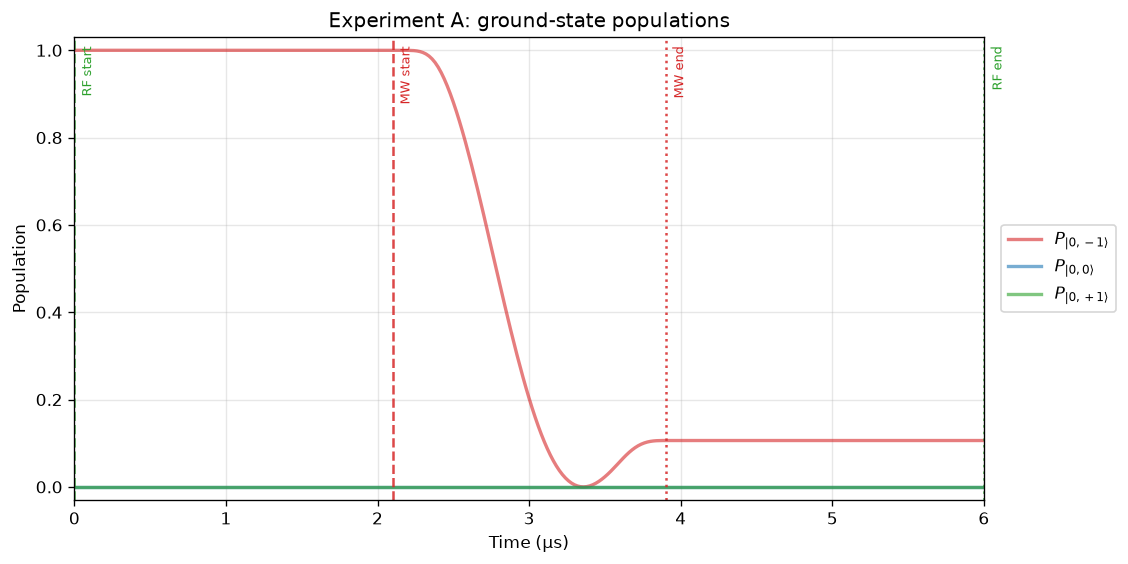

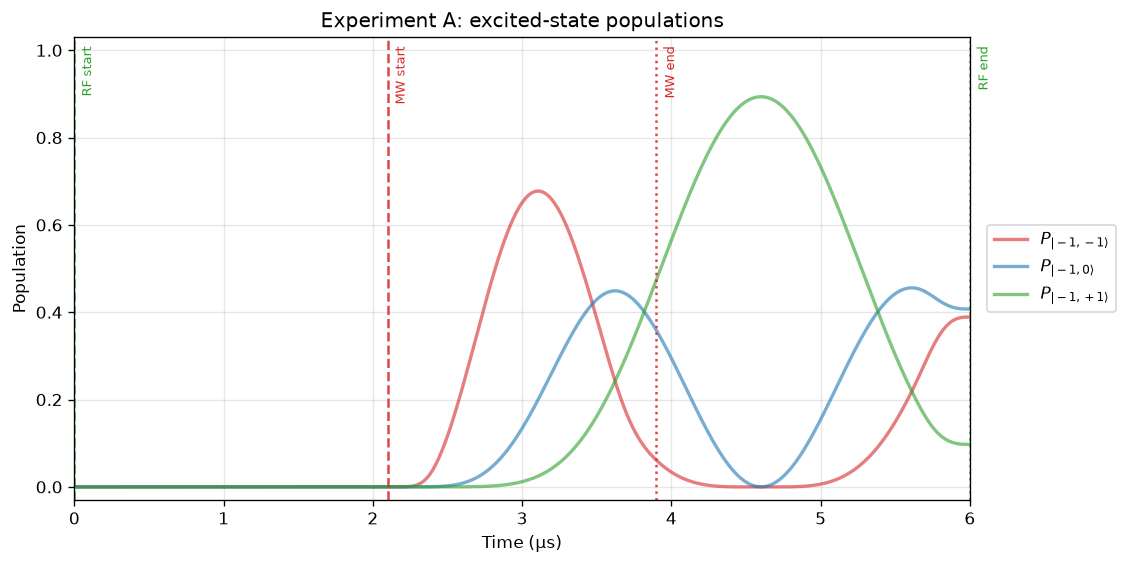

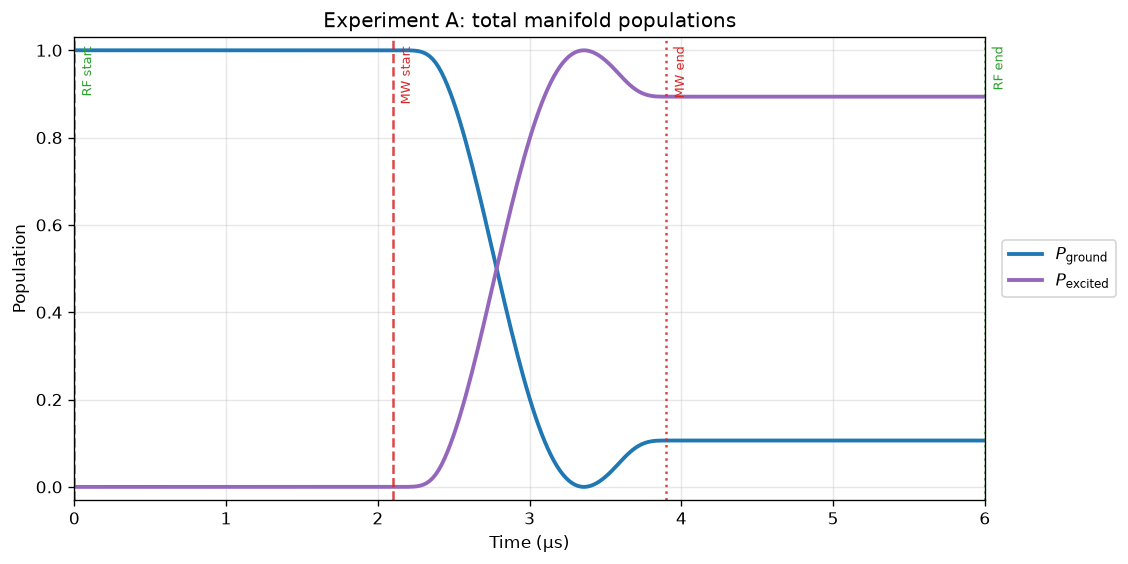

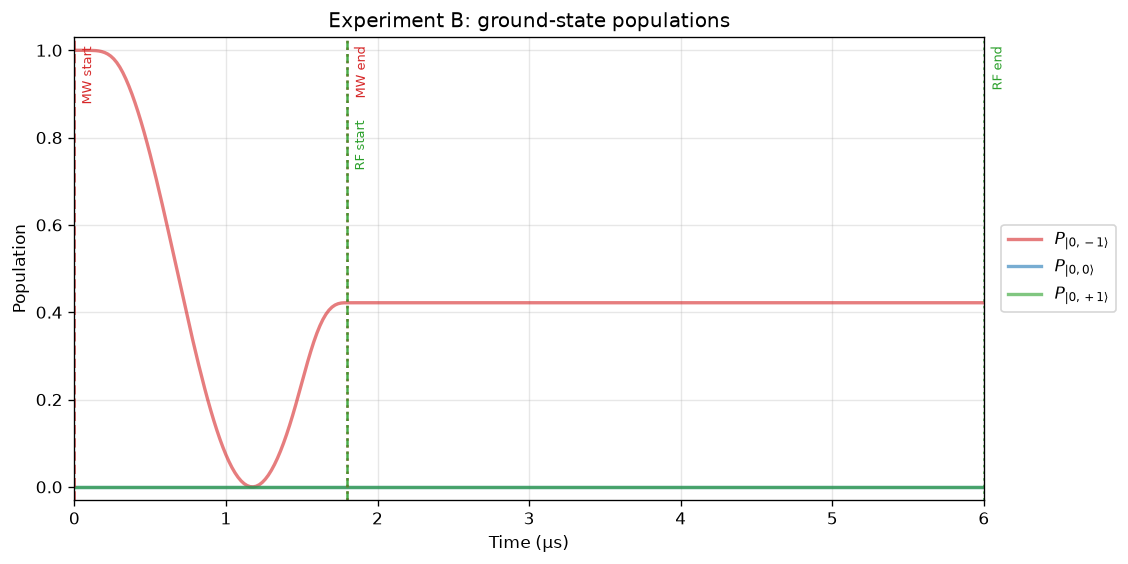

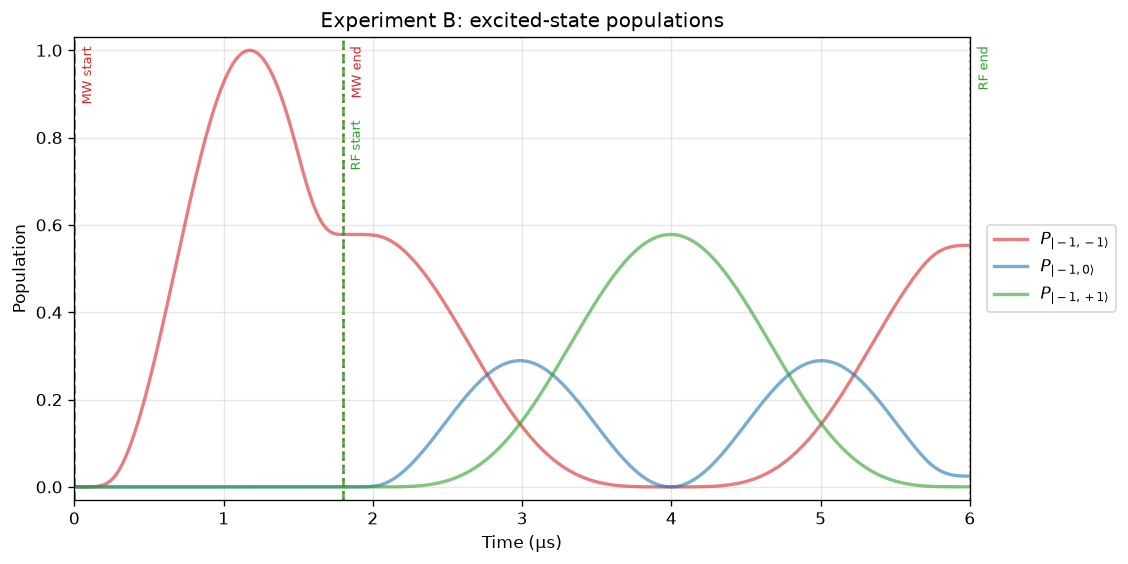

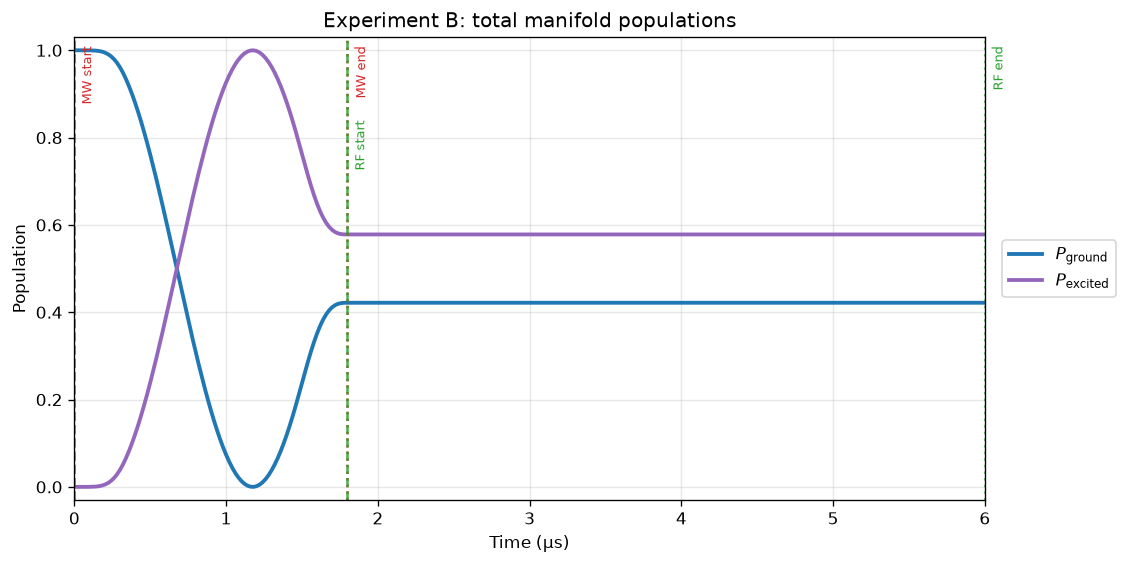

Final A-B population difference:
  P_g_-1: -0.315569
   P_g_0: +0.000000
  P_g_+1: +0.000000
  P_e_-1: -0.164227
   P_e_0: +0.382697
  P_e_+1: +0.097099


In [33]:
population_labels = {
    "P_g_-1": r"$P_{|0,-1\rangle}$",
    "P_g_0": r"$P_{|0,0\rangle}$",
    "P_g_+1": r"$P_{|0,+1\rangle}$",
    "P_e_-1": r"$P_{|-1,-1\rangle}$",
    "P_e_0": r"$P_{|-1,0\rangle}$",
    "P_e_+1": r"$P_{|-1,+1\rangle}$",
}
state_colors = ("tab:red", "tab:blue", "tab:green")
pulse_events = {
    "A": (("RF start", 0.0, "tab:green", "--"),
          ("MW start", 2.1, "tab:red", "--"),
          ("MW end", 2.1 + MW_DURATION_US, "tab:red", ":"),
          ("RF end", TOTAL_TIME_US, "tab:green", ":")),
    "B": (("MW start", 0.0, "tab:red", "--"),
          ("MW end", MW_DURATION_US, "tab:red", ":"),
          ("RF start", MW_DURATION_US, "tab:green", "--"),
          ("RF end", TOTAL_TIME_US, "tab:green", ":")),
}

def add_pulse_boundaries(ax, experiment_name):
    """Mark every pulse-envelope boundary, including coincident events."""
    repeated_time_count = {}
    for label, event_time, color, linestyle in pulse_events[experiment_name]:
        occurrence = repeated_time_count.get(event_time, 0)
        repeated_time_count[event_time] = occurrence + 1
        ax.axvline(event_time, color=color, ls=linestyle, lw=1.5, alpha=0.85)
        ax.annotate(
            label, xy=(event_time, 0.98 - 0.16 * occurrence),
            xycoords=("data", "axes fraction"), xytext=(4, 0),
            textcoords="offset points", rotation=90, va="top",
            ha="left", color=color, fontsize=8,
        )

def finish_population_plot(ax, title, experiment_name):
    add_pulse_boundaries(ax, experiment_name)
    ax.set(
        title=f"Experiment {experiment_name}: {title}",
        xlabel="Time (µs)", ylabel="Population",
        xlim=(0.0, TOTAL_TIME_US), ylim=(-0.03, 1.03),
    )
    ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5))
    ax.figure.tight_layout()
    plt.show()

def plot_experiment_populations(populations, experiment_name):
    # Figure 1: each state in the derived m_s=0 (ground) manifold.
    fig, ax = plt.subplots(figsize=(9.5, 4.8))
    for index, (key, color) in enumerate(zip(list(projectors)[:3], state_colors)):
        ax.plot(t_us, populations[index], color=color, lw=2, label=population_labels[key], alpha=0.6)
    finish_population_plot(ax, "ground-state populations", experiment_name)

    # Figure 2: each state in the derived m_s=-1 (excited) manifold.
    fig, ax = plt.subplots(figsize=(9.5, 4.8))
    for index, (key, color) in enumerate(zip(list(projectors)[3:], state_colors), start=3):
        ax.plot(t_us, populations[index], color=color, lw=2, label=population_labels[key], alpha=0.6)
    finish_population_plot(ax, "excited-state populations", experiment_name)

    # Figure 3: total population in each of the two retained manifolds.
    total_ground = populations[:3].sum(axis=0)
    total_excited = populations[3:].sum(axis=0)
    fig, ax = plt.subplots(figsize=(9.5, 4.8))
    ax.plot(t_us, total_ground, color="tab:blue", lw=2.3, label=r"$P_{\rm ground}$")
    ax.plot(t_us, total_excited, color="tab:purple", lw=2.3, label=r"$P_{\rm excited}$")
    finish_population_plot(ax, "total manifold populations", experiment_name)
    return total_ground, total_excited

total_ground_A, total_excited_A = plot_experiment_populations(pop_A, "A")
total_ground_B, total_excited_B = plot_experiment_populations(pop_B, "B")

assert np.allclose(total_ground_A + total_excited_A, 1.0, atol=2e-6)
assert np.allclose(total_ground_B + total_excited_B, 1.0, atol=2e-6)

final_difference = pop_A[:, -1] - pop_B[:, -1]
print("Final A-B population difference:")
for key, delta in zip(projectors, final_difference):
    print(f"  {key:>6s}: {delta:+.6f}")
